In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/Dataset - minor project /AugmentedAlzheimerDataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

In [ ]:
DATA_DIR = "/content/dataset/AugmentedAlzheimerDataset"

In [ ]:
import os

print(os.listdir(DATA_DIR))

['VeryMildDemented', 'ModerateDemented', 'MildDemented', 'NonDemented']


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm import tqdm
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [ ]:
# Set environment variable for number of workers
# os.environ["NUM_WORKERS"] = "4"

In [ ]:
# Global Parameters
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

BATCH_SIZE = 32
NUM_EPOCHS = 5   # keep small for quick run
LEARNING_RATE = 5e-5

# Use correct dataset path
dataset_path = DATA_DIR

# Class names (must match folder names)
label_names = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
NUM_CLASSES = len(label_names)

print(f"Device set to: {DEVICE} 🚀")
print(f"Dataset path: {dataset_path}")
print(f"Number of classes: {NUM_CLASSES} ({label_names})")

Device set to: cuda 🚀
Dataset path: /content/dataset/AugmentedAlzheimerDataset
Number of classes: 4 (['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented'])


In [ ]:
## 3. Data Augmentation, Loading, and Splitting

#Since the dataset is not pre-split into `train` and `test` folders, we will load all images from the `Data` folder and perform a code-based **70% Train, 15% Validation, 15% Test** split.

In [ ]:
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

# Simple transforms (safe)
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Custom Dataset (replaces ImageFolder + random_split logic)
class CustomDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
        self.label_map = {label:i for i, label in enumerate(sorted(set(labels)))}

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        label = self.label_map[self.labels[idx]]

        if self.transform:
            img = self.transform(img)

        return img, label

print("✅ Custom dataset + transforms ready")

✅ Custom dataset + transforms ready


In [ ]:
from sklearn.model_selection import train_test_split
import os

image_paths = []
labels = []

# 🔥 ONLY use correct class folders
for class_name in label_names:
    class_path = os.path.join(dataset_path, class_name)

    for img in os.listdir(class_path):
        image_paths.append(os.path.join(class_path, img))
        labels.append(class_name)

print("Total images:", len(image_paths))
print("Class distribution (full):", {c: labels.count(c) for c in label_names})

# ✅ Stratified split
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.3, stratify=labels, random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

# 🔍 CHECK SPLIT
from collections import Counter
print("Train split:", Counter(train_labels))
print("Val split:", Counter(val_labels))
print("Test split:", Counter(test_labels))

Total images: 33984
Class distribution (full): {'MildDemented': 8960, 'ModerateDemented': 6464, 'NonDemented': 9600, 'VeryMildDemented': 8960}
Train split: Counter({'NonDemented': 6720, 'VeryMildDemented': 6272, 'MildDemented': 6272, 'ModerateDemented': 4524})
Val split: Counter({'NonDemented': 1440, 'MildDemented': 1344, 'VeryMildDemented': 1344, 'ModerateDemented': 970})
Test split: Counter({'NonDemented': 1440, 'MildDemented': 1344, 'VeryMildDemented': 1344, 'ModerateDemented': 970})


In [ ]:
## 5. Model Definition (ResNet18)

In [ ]:
class AlzheimerModel(nn.Module):
    def __init__(self, num_classes):
        super(AlzheimerModel, self).__init__()

        self.model = models.resnet18(weights='IMAGENET1K_V1')

        # Freeze all layers
        for param in self.model.parameters():
            param.requires_grad = False

        # Unfreeze last layers
        for param in self.model.layer3.parameters():
            param.requires_grad = True

        for param in self.model.layer4.parameters():
            param.requires_grad = True

        num_ftrs = self.model.fc.in_features

        self.model.fc = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.7),  # 🔥 increased dropout
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.model(x)

model = AlzheimerModel(NUM_CLASSES).to(DEVICE)

In [ ]:
## 6. Training Functions

In [ ]:
def train_fn(loader, model, optimizer, loss_fn, scaler):
    model.train()
    loop = tqdm(loader, desc="Training")
    total_loss = 0

    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(DEVICE)
        targets = targets.to(DEVICE)

        # Forward
        with torch.cuda.amp.autocast():
            predictions = model(data)
            loss = loss_fn(predictions, targets)

        # Backward
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    return total_loss / len(loader)

def val_fn(loader, model, loss_fn):
    model.eval()
    loop = tqdm(loader, desc="Validation")
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, targets in loop:
            data = data.to(DEVICE)
            targets = targets.to(DEVICE)

            predictions = model(data)
            loss = loss_fn(predictions, targets)
            total_loss += loss.item()

            # Save predictions and targets for metric calculation
            _, predicted_classes = predictions.max(1)
            all_preds.extend(predicted_classes.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    avg_loss = total_loss / len(loader)

    # Calculate F1-score
    f1 = f1_score(all_targets, all_preds, average='weighted')

    return avg_loss, f1

In [ ]:
# 🔥 CREATE DATASETS (THIS IS MISSING)

train_dataset = CustomDataset(train_paths, train_labels, train_transform)
val_dataset = CustomDataset(val_paths, val_labels, val_transform)
test_dataset = CustomDataset(test_paths, test_labels, val_transform)

print("✅ Datasets created")

✅ Datasets created


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("✅ DataLoaders ready")

✅ DataLoaders ready


In [ ]:
## 7. Training Loop

In [ ]:
## 7. Training Loop

from collections import Counter
import torch

# 🔍 Debug: check class distribution
print("Class distribution (train):", Counter(train_labels))

# 🔥 Compute class weights safely (for ALL 4 classes)
counts = Counter(train_labels)
total = sum(counts.values())

weights = []
for c in label_names:
    weights.append(total / counts[c] if counts[c] > 0 else 0.0)

weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)
print("Class weights:", weights)

# Loss, optimizer, scaler
loss_fn = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler()

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.1, patience=3
)

best_val_f1 = 0.0
train_losses, val_losses, val_f1_scores = [], [], []

print("\nStarting training...")

for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")

    # Training
    train_loss = train_fn(train_loader, model, optimizer, loss_fn, scaler)
    train_losses.append(train_loss)

    # Validation
    val_loss, val_f1 = val_fn(val_loader, model, loss_fn)
    val_losses.append(val_loss)
    val_f1_scores.append(val_f1)

    # Scheduler step
    scheduler.step(val_f1)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1-Score: {val_f1:.4f}")

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        checkpoint = {
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "best_val_f1": best_val_f1,
            "epoch": epoch
        }
        torch.save(checkpoint, "best_model.pth.tar")
        print("✅ New best model saved!")

print("\nTraining complete!")
print(f"Best Validation F1-Score: {best_val_f1:.4f}")

/tmp/ipykernel_13429/4039616964.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Class distribution (train): Counter({'NonDemented': 6720, 'VeryMildDemented': 6272, 'MildDemented': 6272, 'ModerateDemented': 4524})
Class weights: tensor([3.7927, 5.2582, 3.5399, 3.7927], device='cuda:0')

Starting training...

--- Epoch 1/5 ---


Training:   0%|          | 0/744 [00:00<?, ?it/s]/tmp/ipykernel_13429/2195272452.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation: 100%|██████████| 160/160 [00:15<00:00, 10.04it/s]


Train Loss: 0.6509 | Val Loss: 0.3780 | Val F1-Score: 0.8329
✅ New best model saved!

--- Epoch 2/5 ---


Training:   0%|          | 0/744 [00:00<?, ?it/s]/tmp/ipykernel_13429/2195272452.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation: 100%|██████████| 160/160 [00:13<00:00, 11.47it/s]


...

Train Loss: 0.1371 | Val Loss: 0.1746 | Val F1-Score: 0.9290
✅ New best model saved!

--- Epoch 4/5 ---


Training:   0%|          | 0/744 [00:00<?, ?it/s]/tmp/ipykernel_13429/2195272452.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation: 100%|██████████| 160/160 [00:14<00:00, 11.33it/s]


Train Loss: 0.0884 | Val Loss: 0.1620 | Val F1-Score: 0.9406
✅ New best model saved!

--- Epoch 5/5 ---


Training:   0%|          | 0/744 [00:00<?, ?it/s]/tmp/ipykernel_13429/2195272452.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation: 100%|██████████| 160/160 [00:13<00:00, 12.14it/s]


Train Loss: 0.0594 | Val Loss: 0.1286 | Val F1-Score: 0.9487
✅ New best model saved!

Training complete!
Best Validation F1-Score: 0.9487


In [ ]:
## 8. Evaluation on Test Set

#We will now evaluate the best saved model on the dedicated **Test Set** (15% of the total data) to get a final, unbiased performance metric.

In [ ]:
## 8. Evaluation on Test Set

def check_accuracy(loader, model):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Testing"):
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            scores = model(x)
            _, predictions = scores.max(1)

            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    return all_targets, all_preds


# Load best model safely
try:
    checkpoint = torch.load("best_model.pth.tar", map_location=DEVICE)
    model.load_state_dict(checkpoint["state_dict"])
    print(f"Loaded best model from epoch {checkpoint['epoch']} with F1: {checkpoint['best_val_f1']:.4f}")
except FileNotFoundError:
    print("WARNING: best_model.pth.tar not found. Using current model state for testing.")


# Run evaluation
test_targets, test_preds = check_accuracy(test_loader, model)

print("\n--- Final Test Set Classification Report ---")
print(classification_report(test_targets, test_preds, target_names=label_names, digits=4))

Loaded best model from epoch 4 with F1: 0.9487


Testing: 100%|██████████| 160/160 [00:13<00:00, 12.22it/s]


--- Final Test Set Classification Report ---
                  precision    recall  f1-score   support

    MildDemented     0.9789    0.9658    0.9723      1344
ModerateDemented     0.9979    1.0000    0.9990       970
     NonDemented     0.9492    0.8944    0.9210      1440
VeryMildDemented     0.8822    0.9472    0.9135      1344

        accuracy                         0.9472      5098
       macro avg     0.9520    0.9518    0.9514      5098
    weighted avg     0.9486    0.9472    0.9474      5098



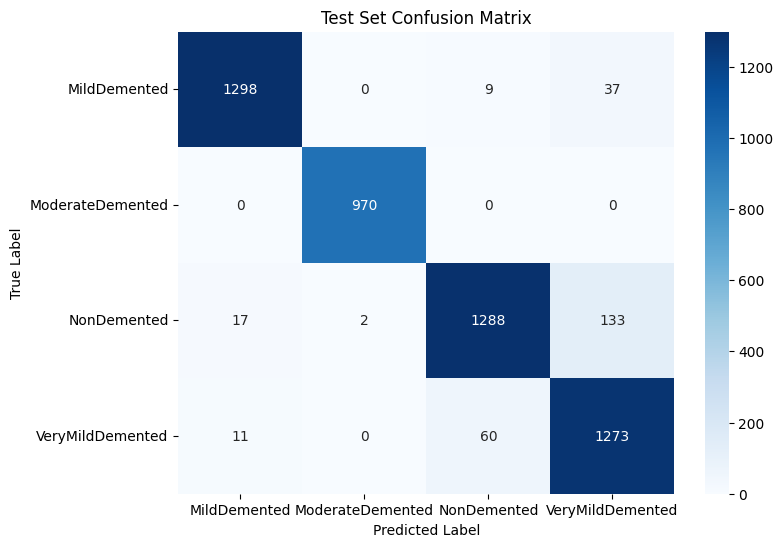

In [ ]:
# Confusion Matrix Visualization
cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Set Confusion Matrix')
plt.show()

Device: cuda
Testing on: /content/dataset/OriginalDataset
✅ Model loaded
Classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


Testing new dataset: 100%|██████████| 200/200 [00:22<00:00,  8.75it/s]



--- Classification Report ---
                  precision    recall  f1-score   support

    MildDemented     0.9876    0.9810    0.9843       896
ModerateDemented     1.0000    1.0000    1.0000        64
     NonDemented     0.9860    0.9675    0.9767      3200
VeryMildDemented     0.9532    0.9812    0.9670      2240

        accuracy                         0.9745      6400
       macro avg     0.9817    0.9824    0.9820      6400
    weighted avg     0.9749    0.9745    0.9746      6400



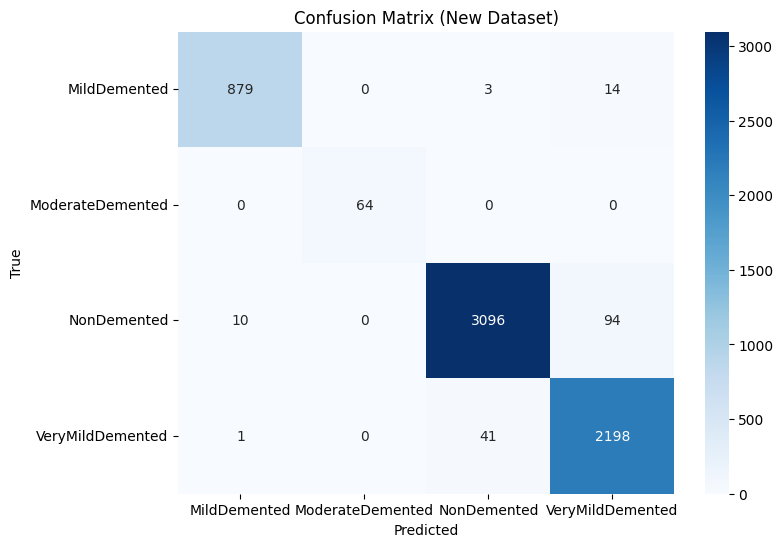

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Setup ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 32

original_label_names = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
NUM_CLASSES = len(original_label_names)

# 🔥 SET CORRECT PATH (CHANGE IF NEEDED)
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/Dataset - minor project /OriginalDataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')
new_dataset_path = "/content/dataset/OriginalDataset"

print(f"Device: {DEVICE}")
print(f"Testing on: {new_dataset_path}")

# --- 2. Transforms (same as validation) ---
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# --- 3. Model (same as training) ---
class AlzheimerModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.resnet18(weights=None)

        for param in self.model.parameters():
            param.requires_grad = False

        for param in self.model.layer3.parameters():
            param.requires_grad = True

        for param in self.model.layer4.parameters():
            param.requires_grad = True

        num_ftrs = self.model.fc.in_features

        self.model.fc = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.7),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.model(x)

model = AlzheimerModel(NUM_CLASSES).to(DEVICE)

# --- 4. Load weights ---
checkpoint = torch.load("best_model.pth.tar", map_location=DEVICE)
model.load_state_dict(checkpoint["state_dict"])
print("✅ Model loaded")

# --- 5. Load dataset ---
dataset = datasets.ImageFolder(new_dataset_path, transform=val_transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", dataset.classes)

# --- 6. Evaluation ---
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in tqdm(loader, desc="Testing new dataset"):
        x, y = x.to(DEVICE), y.to(DEVICE)

        outputs = model(x)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.cpu().numpy())

# --- 7. Report ---
print("\n--- Classification Report ---")
print(classification_report(all_targets, all_preds, target_names=dataset.classes, digits=4))

# --- 8. Confusion Matrix ---
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (New Dataset)")
plt.show()

In [ ]:
print(os.listdir("/content/dataset"))

['AugmentedAlzheimerDataset', 'OriginalDataset']


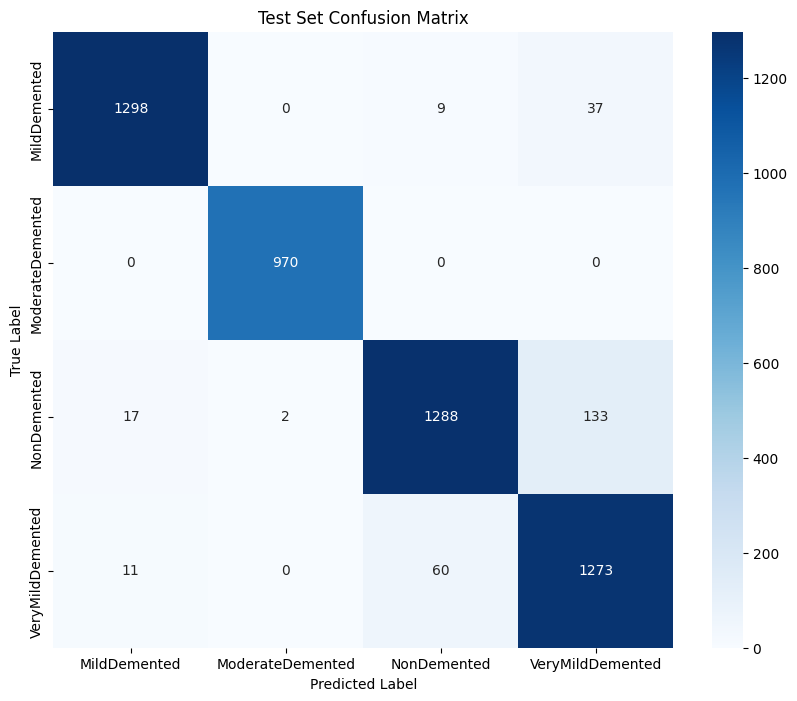

In [ ]:
cm = confusion_matrix(test_targets, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Set Confusion Matrix')

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Accuracy
accuracy = accuracy_score(test_targets, test_preds)

# Precision, Recall, F1 (weighted for imbalance)
precision = precision_score(test_targets, test_preds, average='weighted')
recall = recall_score(test_targets, test_preds, average='weighted')
f1 = f1_score(test_targets, test_preds, average='weighted')

print("📊CNN Model Performance:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

📊CNN Model Performance:
Accuracy  : 0.9472
Precision : 0.9486
Recall    : 0.9472
F1 Score  : 0.9474
